In [3]:
# %%
# =============================
# A) 全局样式与通用工具（PDF 嵌字 + 统一线宽/字号 + 可定位徽标）
# =============================
import os, math
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional, Callable
from fractions import Fraction
from collections import deque
from cycler import cycler

# ---- PRA 风格（更粗线、更大字；出版友好） ----
def set_pra_style():
    mpl.rcParams.update({
        # 字体与矢量输出
        "mathtext.fontset": "stix",
        "font.family": "STIXGeneral",
        "text.usetex": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,

        # 尺寸与字号（全局基线，具体图里再加粗/放大）
        "figure.figsize": (6.0, 3.6),
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "legend.fontsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,

        # 线宽与标记尺寸（基线）
        "axes.linewidth": 1.0,
        "lines.linewidth": 1.2,
        "lines.markersize": 5.0,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.minor.width": 0.8,
        "ytick.minor.width": 0.8,

        # 轴脊线与网格
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": ":",
        "grid.linewidth": 0.6,

        "axes.unicode_minus": False,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "figure.autolayout": False,
        "xtick.direction": "out",
        "ytick.direction": "out",

        # 颜色循环（Tableau 10）
        "axes.prop_cycle": cycler(color=[
            "#1f77b4","#ff7f0e","#2ca02c","#d62728",
            "#9467bd","#8c564b","#e377c2","#7f7f7f",
            "#bcbd22","#17becf"
        ]),
        # 圆角端
        "lines.solid_capstyle": "round",
        "lines.solid_joinstyle": "round",
    })
set_pra_style()

# 统一输出目录
OUTDIR = "figs_core"
os.makedirs(OUTDIR, exist_ok=True)

def savefig(fig, name: str, dpi_png: int = 500, show: bool = True, width: Optional[int] = 900):
    """保存 PDF/PNG（嵌入字体），并打印路径。"""
    pdf = os.path.join(OUTDIR, f"{name}.pdf")
    png = os.path.join(OUTDIR, f"{name}.png")
    meta = {"Title": name, "Creator": "pra-style"}
    fig.savefig(pdf, bbox_inches="tight", metadata=meta)
    fig.savefig(png, bbox_inches="tight", dpi=dpi_png, metadata=meta)
    if show:
        from IPython.display import display
        from IPython.display import Image as IPyImage
        display(IPyImage(filename=png, width=width))
    plt.close(fig)
    print(f"[Saved] {pdf}  {png}")

# ---- 简洁茎图（更粗） ----
def stem_plot(ax, x, y, marker="o"):
    for xi, yi in zip(x, y):
        ax.plot([xi, xi], [0, yi], lw=1.1, color="0.50", alpha=0.95, zorder=1)
        ax.plot([xi], [yi], marker=marker, ms=5.6, mfc="white", mec="0.15", mew=1.1, color="0.15", zorder=2)
    ax.axhline(0, linewidth=1.1, color="0.35", alpha=0.9, zorder=0.5)

# ---- 角落徽标：支持 loc 与 pos（返回 artist 便于二次微调） ----
def _loc2anchor(loc):
    return {
        "br": (0.98, 0.02, "right", "bottom"),
        "bl": (0.02, 0.02, "left",  "bottom"),
        "tr": (0.98, 0.98, "right", "top"),
        "tl": (0.02, 0.98, "left",  "top"),
    }[loc]

def slope_box(ax, text, loc="br", pos: Optional[Tuple[float,float]]=None, fontsize=10, box_alpha=0.96):
    if pos is None:
        x, y, ha, va = _loc2anchor(loc)
    else:
        x, y = pos; ha, va = "left", "bottom"
    artist = ax.text(
        x, y, text, transform=ax.transAxes, ha=ha, va=va, fontsize=fontsize,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.85", alpha=box_alpha),
    )
    return artist

def unit_badge(ax, q: Optional[int] = None, loc="br", pos: Optional[Tuple[float,float]]=None, fontsize=10):
    txt = r""
    if q is not None and isinstance(q, (int, np.integer)) and q > 1:
        txt = rf"integerized: $\gamma'=\gamma/{q},\ \omega'={q}\omega\in\mathbb{{Z}}$"
    if not txt:
        return None
    return slope_box(ax, txt, loc=loc, pos=pos, fontsize=fontsize)

def method_badge_twopoint(ax, Lambda_sym=r"\Lambda", loc="bl",
                          pos: Optional[Tuple[float,float]]=None, fontsize=10, box_alpha=0.96,
                          M_mode: str = "total", newline_before_note: bool=False):
    if M_mode == "total":
        M_sym, note = "M", "(M = total)"
    elif M_mode == "per_endpoint":
        M_sym, note = r"M_{\mathrm{ep}}", "(per endpoint)"
    else:
        M_sym, note = str(M_mode), ""
    prefix = ""
    math   = rf"$\operatorname{{Var}}[\hat{{g}}]\leq 4\,\alpha^2\,{Lambda_sym}^2/{M_sym}$"
    suffix = (("\n" if newline_before_note else " ") + note) if note else ""
    txt = prefix + math + suffix
    return slope_box(ax, txt, loc=loc, pos=pos, fontsize=fontsize, box_alpha=box_alpha)

def middle_slice_idx(n, frac=0.6):
    k = max(2, int(round(n * frac)))
    start = (n - k) // 2
    return slice(start, start + k)


In [4]:
# %%
# =============================
# B) PennyLane 电路与 f_true（shots 传入时转 int）
# =============================
import pennylane as qml

def _build_qaoa_expectation(n, edges_w, p, gammas, betas, ell, shots=None):
    if shots is not None:
        shots = int(shots)
        if shots <= 0:
            raise ValueError("shots must be a positive integer")
    coeffs = [w for (_, _, w) in edges_w]
    ops    = [qml.PauliZ(i) @ qml.PauliZ(j) for (i, j, _) in edges_w]
    H_cost = qml.Hamiltonian(coeffs, ops)
    dev = qml.device("default.qubit", wires=n, shots=shots)

    @qml.qnode(dev)
    def circuit(gamma_var: float):
        for w in range(n):
            qml.Hadamard(wires=w)
        for k in range(1, p+1):
            gk = gamma_var if k == ell else gammas[k-1]
            for (i, j, w) in edges_w:
                qml.IsingZZ(2.0 * gk * w, wires=[i, j])
            for q in range(n):
                qml.RX(2.0 * betas[k-1], wires=q)
        return qml.expval(H_cost)
    return circuit

def make_f_true_pennylane(n, edges_w, p, gammas_fixed, betas_fixed, ell, shots_for_eval=None):
    shot_val = None if shots_for_eval is None else int(shots_for_eval)
    if shot_val is not None and shot_val <= 0:
        raise ValueError("shots_for_eval must be a positive integer")
    circuit = _build_qaoa_expectation(n, edges_w, p, gammas_fixed, betas_fixed, ell, shots=shot_val)
    def f_true(gamma: float) -> float:
        return float(circuit(gamma))
    return f_true


In [5]:
# %%
# =============================
# C) 频谱恢复（含 DC/Nyquist）与频域工具
# =============================
def rational_denominator(weights: List[float], max_den: int = 32) -> int:
    q = 1
    for w in weights:
        frac = Fraction(w).limit_denominator(max_den)
        q = np.lcm(q, frac.denominator)
    return int(q)

def recover_spectrum_via_dft(f_callable, q, K_int_guess, N=None, drop_tol=1e-10):
    if N is None:
        N = 4 * K_int_guess + 4
    gammap = np.linspace(0, 2*np.pi, N, endpoint=False)  # γ' = γ / q
    fvals  = np.array([f_callable(gp / q) for gp in gammap], dtype=np.float64)
    F      = np.fft.fft(fvals) / N

    omega_p, a_p = [], []
    if abs(F[0]) > drop_tol:
        omega_p.append(0.0); a_p.append(F[0].real)

    half = N // 2
    k_hi = half if (N % 2 == 0) else half + 1
    for k in range(1, k_hi):
        amp = F[k]
        if abs(amp) > drop_tol:
            omega_p.append(+k / q); a_p.append(amp)
            omega_p.append(-k / q); a_p.append(np.conjugate(amp))
    if N % 2 == 0:
        k = half
        amp = F[k]
        if abs(amp) > drop_tol:
            omega_p.append(+k / q); a_p.append(amp.real)

    order = np.argsort(omega_p)
    omega = np.array([omega_p[i] for i in order], dtype=np.float64)
    a     = np.array([a_p[i]     for i in order], dtype=np.complex128)
    return omega, a

# 频域计算
def opt_alpha_fixed_s(omega: np.ndarray, s: float) -> float:
    ws = omega * s
    num = np.sum(omega * np.sin(ws))
    den = 2.0 * np.sum(np.sin(ws) ** 2)
    return (1.0 / (2.0 * s)) if abs(den) < 1e-12 else float(num / den)

def kappa_vec(omega: np.ndarray, alpha: float, s: float) -> np.ndarray:
    return omega - 2.0 * alpha * np.sin(omega * s)

def sup_bias_numeric(omega: np.ndarray, a: np.ndarray, alpha: float, s: float, n_grid: int = 2000) -> float:
    gammas = np.linspace(0, 2*np.pi, n_grid, endpoint=False)
    kap = kappa_vec(omega, alpha, s)
    vals = 1j * np.sum((a * kap)[:, None] * np.exp(1j * np.outer(omega, gammas)), axis=0)
    return float(np.max(np.abs(vals)))

def f_from_spectrum(omega: np.ndarray, a: np.ndarray, gamma: np.ndarray) -> np.ndarray:
    expm = np.exp(1j * np.outer(omega, gamma))
    series = (a[:, None] * expm)
    return np.real(np.sum(series, axis=0))

def fprime_from_spectrum(omega: np.ndarray, a: np.ndarray, gamma: np.ndarray) -> np.ndarray:
    expm = np.exp(1j * np.outer(omega, gamma))
    series = ((omega * a)[:, None] * expm)
    return np.real(1j * np.sum(series, axis=0))

# 幂律参考线（log-log）
def add_powerlaw_ref(ax, x, y, slope=-2/3, label=None, where="last", linestyle="--", alpha=0.8, lw=1.4):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if not np.any(m): return
    x = x[m]; y = y[m]
    x0 = x[-1] if where == "last" else x[0]
    y0 = y[-1] if where == "last" else y[0]
    xx = np.geomspace(x.min(), x.max(), 200)
    yy = y0 * (xx / x0) ** slope
    ax.plot(xx, yy, linestyle, alpha=alpha, lw=lw, label=label)


In [6]:
# %%
# =============================
# D) 图论工具（Fig.11 需要；保留）
# =============================
def line_graph(edges: List[Tuple[int,int]]) -> List[List[int]]:
    m = len(edges)
    adj = [[] for _ in range(m)]
    for i in range(m):
        u1, v1 = edges[i]
        for j in range(i+1, m):
            u2, v2 = edges[j]
            if len({u1, v1}.intersection({u2, v2})) > 0:
                adj[i].append(j); adj[j].append(i)
    return adj

def bfs_ball_sizes(adj: List[List[int]], r: int) -> List[int]:
    m = len(adj); sizes = []
    for s in range(m):
        seen = {s}; q = deque([(s, 0)])
        while q:
            u, d = q.popleft()
            if d == r: continue
            for v in adj[u]:
                if v not in seen:
                    seen.add(v); q.append((v, d+1))
        sizes.append(len(seen))
    return sizes


In [7]:
# %%
# =============================
# E) 场景与频谱（路径图；p=3；ell=2）
# =============================
n = 8
edges = [(i, i+1) for i in range(n-1)]  # 路径图
weights = [1.0 for _ in edges]          # 全 1
edges_w = [(i, j, w) for (i, j), w in zip(edges, weights)]

p = 3
ell = 2
gammas_fixed = [0.6, 0.0, -0.4]
betas_fixed  = [0.7, 0.9, -0.5]

# f_true（解析、无噪）
SHOTS_FOR_DFT = None
f_true = make_f_true_pennylane(n, edges_w, p, gammas_fixed, betas_fixed, ell, shots_for_eval=SHOTS_FOR_DFT)

# 整数化分母 q 与频率包络上界（保守）
q_guess = rational_denominator(weights, max_den=32)
print("Estimated q =", q_guess)
K_int_guess = int(sum(2*abs(w) for w in weights))
print("K_int_guess =", K_int_guess)

# 恢复频谱
omega, a = recover_spectrum_via_dft(f_true, q=q_guess, K_int_guess=K_int_guess, N=None)
print("Recovered frequencies:", omega)

# ||C||_inf 的保守上界（后续 s* 公式可能用到）
Lambda = float(sum(abs(w) for w in weights))
print("Lambda (upper bound on ||C||_inf) =", Lambda)


Estimated q = 1
K_int_guess = 14
Recovered frequencies: [-4. -2.  0.  2.  4.]
Lambda (upper bound on ||C||_inf) = 7.0


In [8]:
# %%
# -----------------------------
# E) 图论工具（局域性包络）
# -----------------------------
def line_graph(edges: List[Tuple[int,int]]) -> List[List[int]]:
    m = len(edges)
    adj = [[] for _ in range(m)]
    for i in range(m):
        u1, v1 = edges[i]
        for j in range(i+1, m):
            u2, v2 = edges[j]
            if len({u1, v1}.intersection({u2, v2})) > 0:
                adj[i].append(j); adj[j].append(i)
    return adj

def bfs_ball_sizes(adj: List[List[int]], r: int) -> List[int]:
    m = len(adj)
    sizes = []
    for s in range(m):
        seen = {s}
        q = deque([(s, 0)])
        while q:
            u, d = q.popleft()
            if d == r:
                continue
            for v in adj[u]:
                if v not in seen:
                    seen.add(v); q.append((v, d+1))
        sizes.append(len(seen))
    return sizes

def max_degree_of_graph(n: int, edges: List[Tuple[int,int]]) -> int:
    deg = [0]*n
    for u,v in edges:
        deg[u]+=1; deg[v]+=1
    return max(deg) if deg else 0

def K_upper_bound_path(r: int) -> int:
    return 1 + 2*r

def K_upper_bound_general(r: int, Delta: int) -> float:
    if Delta <= 2:
        return 1 + 2*r
    num = (2*Delta - 2)
    den = (2*Delta - 4)
    return 1.0 + num * ((2*Delta - 3)**r - 1.0) / den


C:\Users\18853\AppData\Local\Temp\ipykernel_50964\2085977144.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


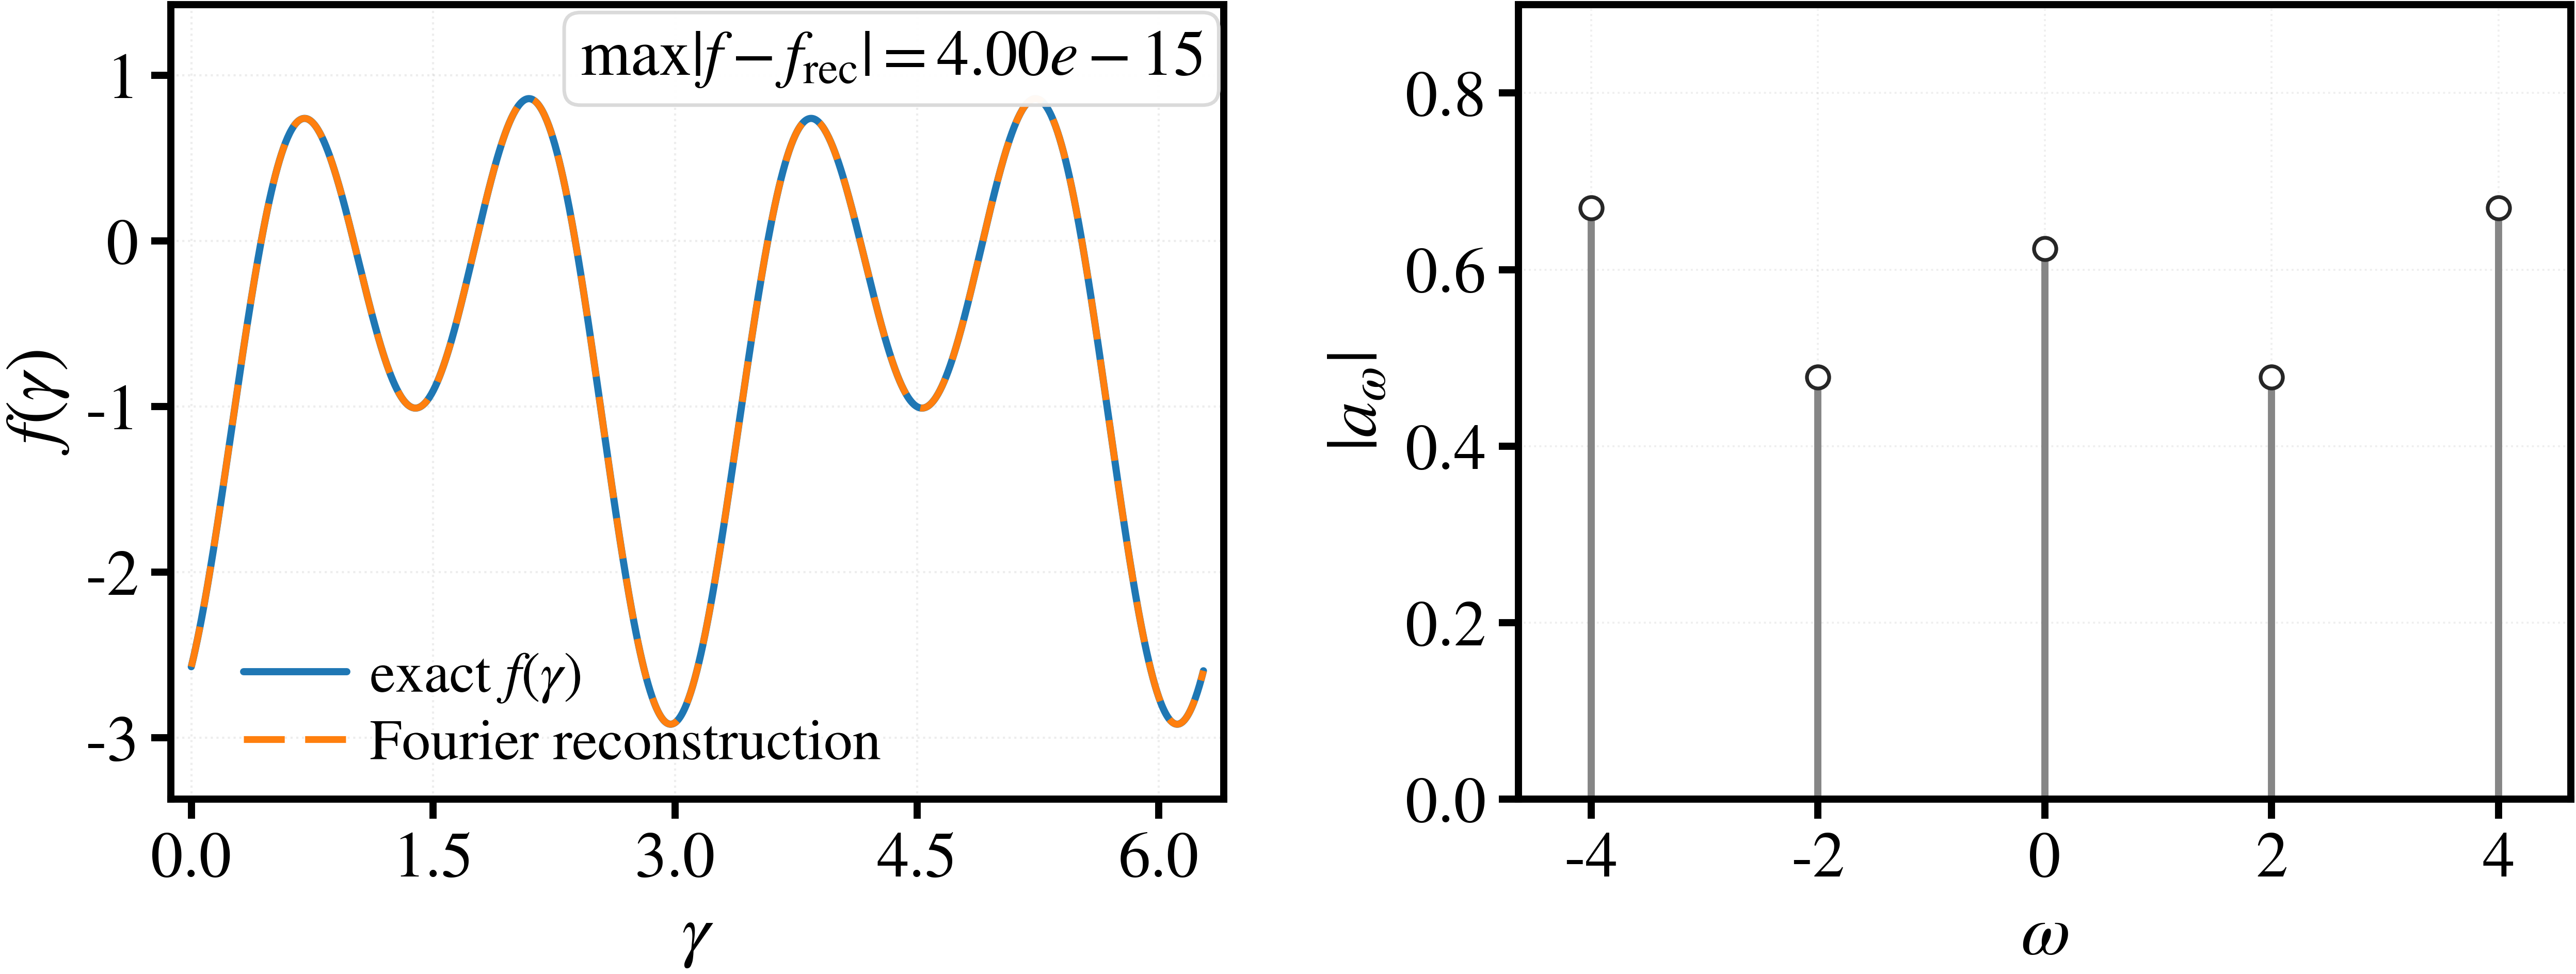

[Saved] figs_core\fig2_unified_style.pdf  figs_core\fig2_unified_style.png


In [9]:
# =====================================
# Fig.2 — 重构校验（左） + 频谱茎图（右）
# 视觉风格完全统一（与 Fig.3 一致）
# =====================================
import numpy as np
import matplotlib.patheffects as pe
from math import ceil
from matplotlib.ticker import MaxNLocator, MultipleLocator, FormatStrFormatter

# -------- 全局视觉参数（与 Fig.3 对齐） --------
FNT_LABEL = 18
FNT_TICK  = 18
FNT_LEG   = 16
FNT_BADGE = 18
LW_MAIN   = 2
LW_AUX    = 2
MS_SCAT   = 6.5

UNIFIED_LW = 2.0   # 四边框线宽统一值
TICK_W     = 2.0
TICK_LEN   = 5.5
LABEL_SIZE = 20

GRID_LW_A      = 0.6
GRID_ALPHA_A   = 0.22
GRID_LW_B      = 0.55
GRID_ALPHA_B   = 0.20
HEADROOM_2A    = 0.15
HEADROOM_2B    = 0.14
STEM_LW        = 2
MARKER_MS      = 6.2
BASELINE_LW    = 1.10

# -------- 图尺寸（与 Fig.3 对齐） --------
FINAL_WIDTH_IN = 12.0
FINAL_HEIGHT_IN = 4.0
ASPECT_2 = FINAL_HEIGHT_IN / FINAL_WIDTH_IN

# -------- 左图数据：重构校验 --------
gamma = np.linspace(0, 2*np.pi, 1000, endpoint=False)
f_true_vals = np.array([f_true(g) for g in gamma], dtype=float)
expm = np.exp(1j * np.outer(omega, gamma))
f_rec_vals = np.real(np.sum((a[:, None] * expm), axis=0))
max_err = float(np.max(np.abs(f_true_vals - f_rec_vals)))

# -------- 创建左右子图 --------
fig, (axL, axR) = plt.subplots(1, 2, figsize=(FINAL_WIDTH_IN, FINAL_HEIGHT_IN),
                               gridspec_kw=dict(wspace=0.28))

# ===================== 左：重构校验 =====================
ax = axL
ax.plot(gamma, f_true_vals, lw=LW_MAIN, label=r"exact $f(\gamma)$")
ax.plot(gamma, f_rec_vals, lw=LW_MAIN*0.95, linestyle=(0,(6,3)),
        label="Fourier reconstruction")

ax.grid(True, linestyle=":", linewidth=GRID_LW_A, alpha=GRID_ALPHA_A)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(axis="both", labelsize=FNT_TICK,
               width=TICK_W, length=TICK_LEN, direction="out")

ax.set_xlabel(r"$\gamma$", fontsize=FNT_LABEL)
ax.set_ylabel(r"$f(\gamma)$", fontsize=FNT_LABEL)

# 紧凑图例
leg = ax.legend(loc="lower left", bbox_to_anchor=(0.02, -0.03),
                frameon=False, handlelength=1.8, handletextpad=0.4,
                labelspacing=0.25, fontsize=FNT_LEG)
for t in leg.get_texts():
    t.set_path_effects([pe.Stroke(linewidth=2.0, foreground="white"), pe.Normal()])

# 误差徽标
badge = rf"$\max|f-f_{{\rm rec}}|={max_err:.2e}$"
if q_guess and int(q_guess) > 1:
    badge += rf"\n($q={int(q_guess)}$ integerized grid)"
tbox = slope_box(ax, badge, loc="tr", fontsize=FNT_BADGE, box_alpha=0.96)
tbox.set_position((0.98, 0.97))

# y 范围与边距
ymin = float(min(f_true_vals.min(), f_rec_vals.min()))
ymax = float(max(f_true_vals.max(), f_rec_vals.max()))
yrng = ymax - ymin if ymax > ymin else 1.0
ax.set_ylim(ymin - 0.12*yrng, ymax + HEADROOM_2A*yrng)
ax.margins(x=0.02, y=0.06)

# ===================== 右：频谱茎图 =====================
ax = axR
ax.grid(True, linestyle=":", linewidth=GRID_LW_B, alpha=GRID_ALPHA_B)

xw = np.asarray(omega, float)
yw = np.abs(np.asarray(a, complex))
for xi, yi in zip(xw, yw):
    ax.plot([xi, xi], [0.0, yi], color="0.50", lw=STEM_LW, alpha=0.95)
    ax.plot([xi], [yi], marker="o", ms=MARKER_MS, mfc="white",
            mec="0.15", mew=1.05, color="0.15")
ax.axhline(0.0, color="0.35", lw=BASELINE_LW, alpha=0.9)

ax.minorticks_off()
ax.tick_params(axis="both", labelsize=FNT_TICK,
               width=TICK_W, length=TICK_LEN, direction="out")
ax.set_xlabel(r"$\omega$", fontsize=FNT_LABEL)
ax.set_ylabel(r"$|a_\omega|$", fontsize=FNT_LABEL)

# ---- y 刻度 0.2 步长 + 顶部留白 ----
tick = 0.2
TOP_PAD_TICKS = 0.5
ymax_data = float(np.nanmax(yw)) if yw.size else 1.0
y_target = ymax_data * (1.0 + HEADROOM_2B)
y_top_tick = tick * ceil(y_target / tick)
ax.set_ylim(0.0, y_top_tick + TOP_PAD_TICKS * tick)
ax.yaxis.set_major_locator(MultipleLocator(tick))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

if q_guess and int(q_guess) > 1:
    unit_badge(ax, q=int(q_guess), loc="br", pos=(0.98, 0.02), fontsize=FNT_BADGE)

ax.margins(x=0.08, y=0.06)

# -------- 四边框统一样式 --------
for axi in (axL, axR):
    for side in ('top', 'right', 'bottom', 'left'):
        axi.spines[side].set_visible(True)
        axi.spines[side].set_linewidth(UNIFIED_LW)
    axi.xaxis.label.set_size(LABEL_SIZE)
    axi.yaxis.label.set_size(LABEL_SIZE)

fig.tight_layout()
savefig(fig, "fig2_unified_style", dpi_png=500, show=True, width=980)


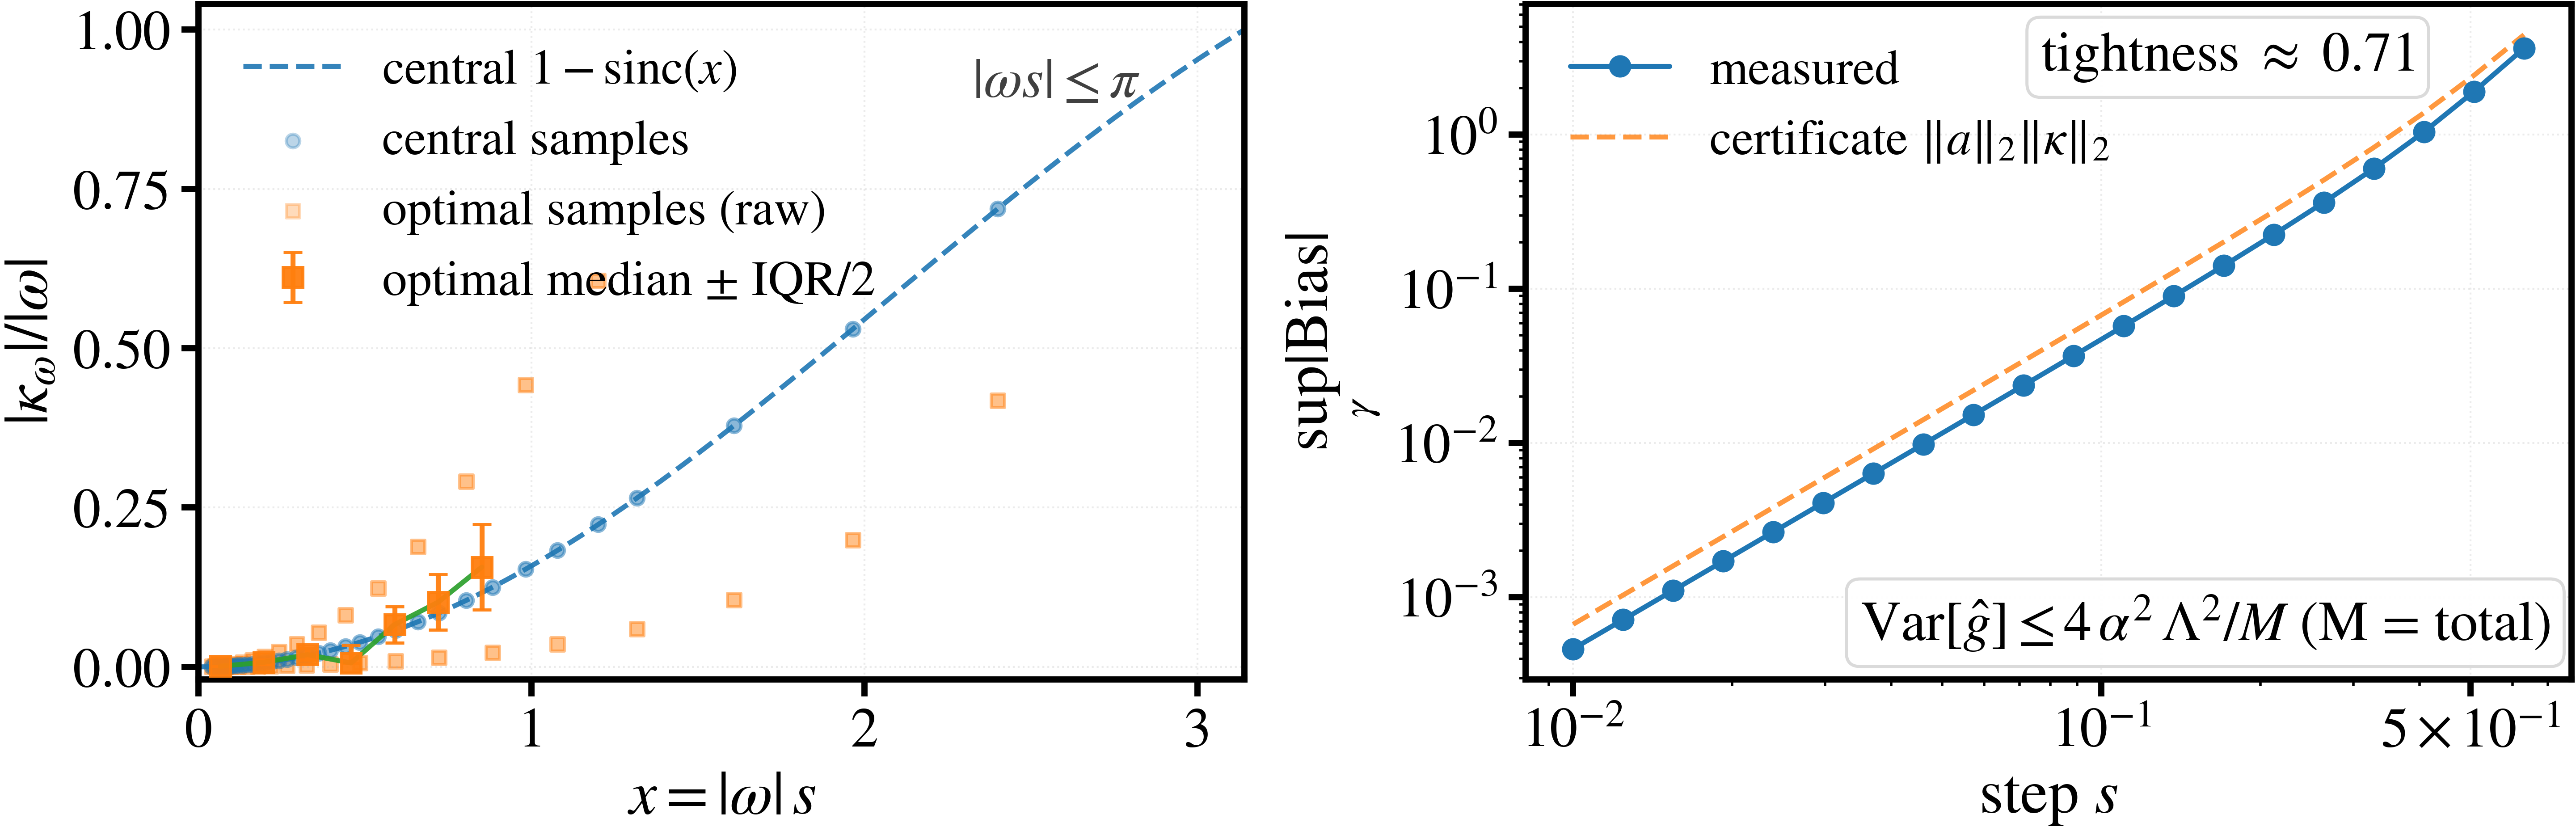

[Saved] figs_core\fig3a_filter_curve.pdf  figs_core\fig3a_filter_curve.png


In [10]:
# =============================
# H) Fig.3 — 频域滤波视图（左） & 证书对比（右）
# =============================
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator, FuncFormatter, NullLocator

def _sinc1(x):
    x = np.asarray(x, float); out = np.ones_like(x)
    m = np.abs(x) > 1e-14
    out[m] = np.sin(x[m]) / x[m]
    return out

# 小工具：log-x 仅保留 10^-2、10^-1、5×10^-1 三个主刻度（按升序）
def _set_three_log_xticks(ax, s_grid):
    xticks = [t for t in (1e-2, 1e-1, 5e-1) if s_grid.min() <= t <= s_grid.max()]
    ax.set_xticks(xticks)
    lab = {1e-2: r"$10^{-2}$", 1e-1: r"$10^{-1}$", 5e-1: r"$5\times10^{-1}$"}
    ax.set_xticklabels([lab[t] for t in xticks])

# 采样多个 s，构造左图散点与分箱统计
s_list = np.geomspace(0.02, 0.6, 18)
xs_c, ys_c, xs_o_raw, ys_o_raw = [], [], [], []
for s in s_list:
    a_c  = 1.0/(2.0*s)
    a_o  = opt_alpha_fixed_s(omega, s)
    k_c  = kappa_vec(omega, a_c, s)
    k_o  = kappa_vec(omega, a_o, s)
    for w, kc, ko in zip(omega, k_c, k_o):
        if np.isclose(w, 0.0): continue
        x = abs(w)*s
        if x <= np.pi * 1.001:
            xs_c.append(x);        ys_c.append(abs(kc)/max(abs(w), 1e-16))
            xs_o_raw.append(x);    ys_o_raw.append(abs(ko)/max(abs(w), 1e-16))
xs_c = np.array(xs_c);     ys_c = np.array(ys_c)
xs_o = np.array(xs_o_raw); ys_o = np.array(ys_o_raw)

# 分箱
nbin = 24
edges_bin = np.linspace(0, np.pi, nbin+1)
centers = 0.5*(edges_bin[:-1] + edges_bin[1:])
med, q1, q3, nbin_count = [], [], [], []
for lo, hi in zip(edges_bin[:-1], edges_bin[1:]):
    sel = (xs_o >= lo) & (xs_o < hi)
    if np.any(sel):
        yb = ys_o[sel]
        med.append(np.median(yb))
        q1.append(np.quantile(yb, 0.25))
        q3.append(np.quantile(yb, 0.75))
        nbin_count.append(sel.sum())
    else:
        med.append(np.nan); q1.append(np.nan); q3.append(np.nan); nbin_count.append(0)
med = np.array(med); q1 = np.array(q1); q3 = np.array(q3); nbin_count = np.array(nbin_count)
lo_err = med - q1
hi_err = q3 - med
ok = (~np.isnan(med)) & (nbin_count >= 3)

# 解析曲线
xx = np.linspace(1e-4, np.pi, 400)
yy_c = 1.0 - _sinc1(xx)

# 右图数据
s_grid = np.logspace(-2.0, -0.2, 20)
a_norm = float(np.linalg.norm(a))
sup_meas, cert = [], []
for s in s_grid:
    a_opt = opt_alpha_fixed_s(omega, s)
    # measured sup|Bias|
    gammas = np.linspace(0.0, 2*np.pi, 512, endpoint=False)
    kap = omega - 2.0*a_opt*np.sin(omega*s)
    vals = 1j * np.sum((a*kap)[:, None] * np.exp(1j*np.outer(omega, gammas)), axis=0)
    sup_meas.append(float(np.max(np.abs(vals))))
    # certificate (L2 × L2)
    cert.append(a_norm * float(np.linalg.norm(kap)))
sup_meas = np.array(sup_meas); cert = np.array(cert)

# certificate ratio（几何平均）
ratio = np.maximum(sup_meas / np.maximum(cert, 1e-300), 1e-300)
gm_tight = float(np.exp(np.mean(np.log(ratio))))

# ---------- 绘图 ----------
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.0))

# 全局视觉参数
FNT_LABEL = 18; FNT_TICK = 18; FNT_LEG = 16; FNT_BADGE = 18
LW_MAIN = 1.6; LW_AUX = 1.6; MS_SCAT = 6.2

# (A) 频域滤波视图（左）
ax = axes[0]
ax.plot(xx, yy_c, '--', lw=LW_AUX, alpha=0.9, label=r'central $1-\mathrm{sinc}(x)$')
ax.scatter(xs_c, ys_c, s=MS_SCAT**2/2, alpha=0.30, label='central samples', zorder=2)
ax.scatter(xs_o, ys_o, s=MS_SCAT**2/2, alpha=0.28, marker='s', label='optimal samples (raw)', zorder=1)
# 注意：图例为 ±IQR/2，因此把误差棒除以 2
ax.errorbar(centers[ok], med[ok], yerr=[lo_err[ok]/2, hi_err[ok]/2],
            fmt='s', ms=MS_SCAT, lw=LW_MAIN, capsize=3, alpha=0.95,
            label='optimal median ± IQR/2', zorder=3)
ax.plot(centers[ok], med[ok], '-', lw=LW_MAIN, alpha=0.92, zorder=3)

# —— 竖线 + 说明（不要顶上的“π”标签）——
ax.set_xlim(0, np.pi); ax.set_ylim(-0.02, 1.04)
ax.axvline(np.pi, ls=":", lw=LW_AUX, color="0.35")
ax.text(0.90, 0.92, r"$|\omega s|\leq \pi$", transform=ax.transAxes,
        ha="right", va="top", fontsize=FNT_TICK, color="0.25")

ax.set_xlabel(r'$x=|\omega|\,s$', fontsize=FNT_LABEL)
ax.set_ylabel(r'$|\kappa_\omega|/|\omega|$', fontsize=FNT_LABEL)
ax.tick_params(axis="both", labelsize=FNT_TICK, width=1.1, length=3.5, direction="out")
ax.legend(loc='upper left', frameon=False, fontsize=FNT_LEG)

# —— 左图 y 轴疏化（保留两位小数，不开次刻度）——
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.2f}"))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both', min_n_ticks=4))
ax.yaxis.set_minor_locator(NullLocator())

# 单位徽标（可自由放置）
badge_L = unit_badge(ax, q=int(q_guess) if q_guess else None, loc="br", fontsize=FNT_BADGE)
if badge_L: badge_L.set_position((0.75, 0.12))

# (B) 证书 vs 实测（log–log，右）
ax = axes[1]
ax.loglog(s_grid, sup_meas, 'o-', lw=LW_MAIN, ms=MS_SCAT, label='measured', zorder=3)
ax.loglog(s_grid, cert, '--', lw=LW_AUX, alpha=0.8, label=rf'certificate $\|a\|_2\|\kappa\|_2$', zorder=2)

# —— 不画 slope 2 参考线（该展示留给 Fig.4 左）——

ax.set_xlabel(r'step $s$', fontsize=FNT_LABEL)
ax.set_ylabel(r'$\sup_\gamma|\mathrm{Bias}|$', fontsize=FNT_LABEL)
ax.tick_params(axis="both", labelsize=FNT_TICK, width=1.1, length=3.5, direction="out")
ax.legend(loc='upper left', frameon=False, fontsize=FNT_LEG)

# —— 右图 x 轴：仅保留 10^-2、10^-1、5×10^-1 三个主刻度（升序）——
_set_three_log_xticks(ax, s_grid)

# 徽标
tight = slope_box(ax, rf"tightness $\approx$ {gm_tight:.2f}", loc="tr", fontsize=FNT_BADGE)
meth  = method_badge_twopoint(ax, Lambda_sym=r"\Lambda", loc="bl", fontsize=FNT_BADGE)
unit  = unit_badge(ax, q=int(q_guess) if q_guess else None, loc="br", fontsize=FNT_BADGE)
tight.set_position((0.85, 0.96))
meth.set_position((0.32, 0.04))

# —— 轴线 & 刻度加粗 —— 
XY_AXIS_LW = 2; TICK_W = 2.0; TICK_LEN = 5.5; LABEL_SIZE = 20
for ax in axes:
    ax.spines['bottom'].set_linewidth(XY_AXIS_LW)
    ax.spines['left'].set_linewidth(XY_AXIS_LW)
    ax.tick_params(axis='x', width=TICK_W, length=TICK_LEN, bottom=True, top=False, direction='out')
    ax.tick_params(axis='y', width=TICK_W, length=TICK_LEN, left=True, right=False, direction='out')
    ax.xaxis.label.set_size(LABEL_SIZE); ax.yaxis.label.set_size(LABEL_SIZE)

for ax in fig.axes:
    for side in ('top','right','bottom','left'):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(2)

fig.tight_layout()
savefig(fig, "fig3a_filter_curve", show=True, width=980)


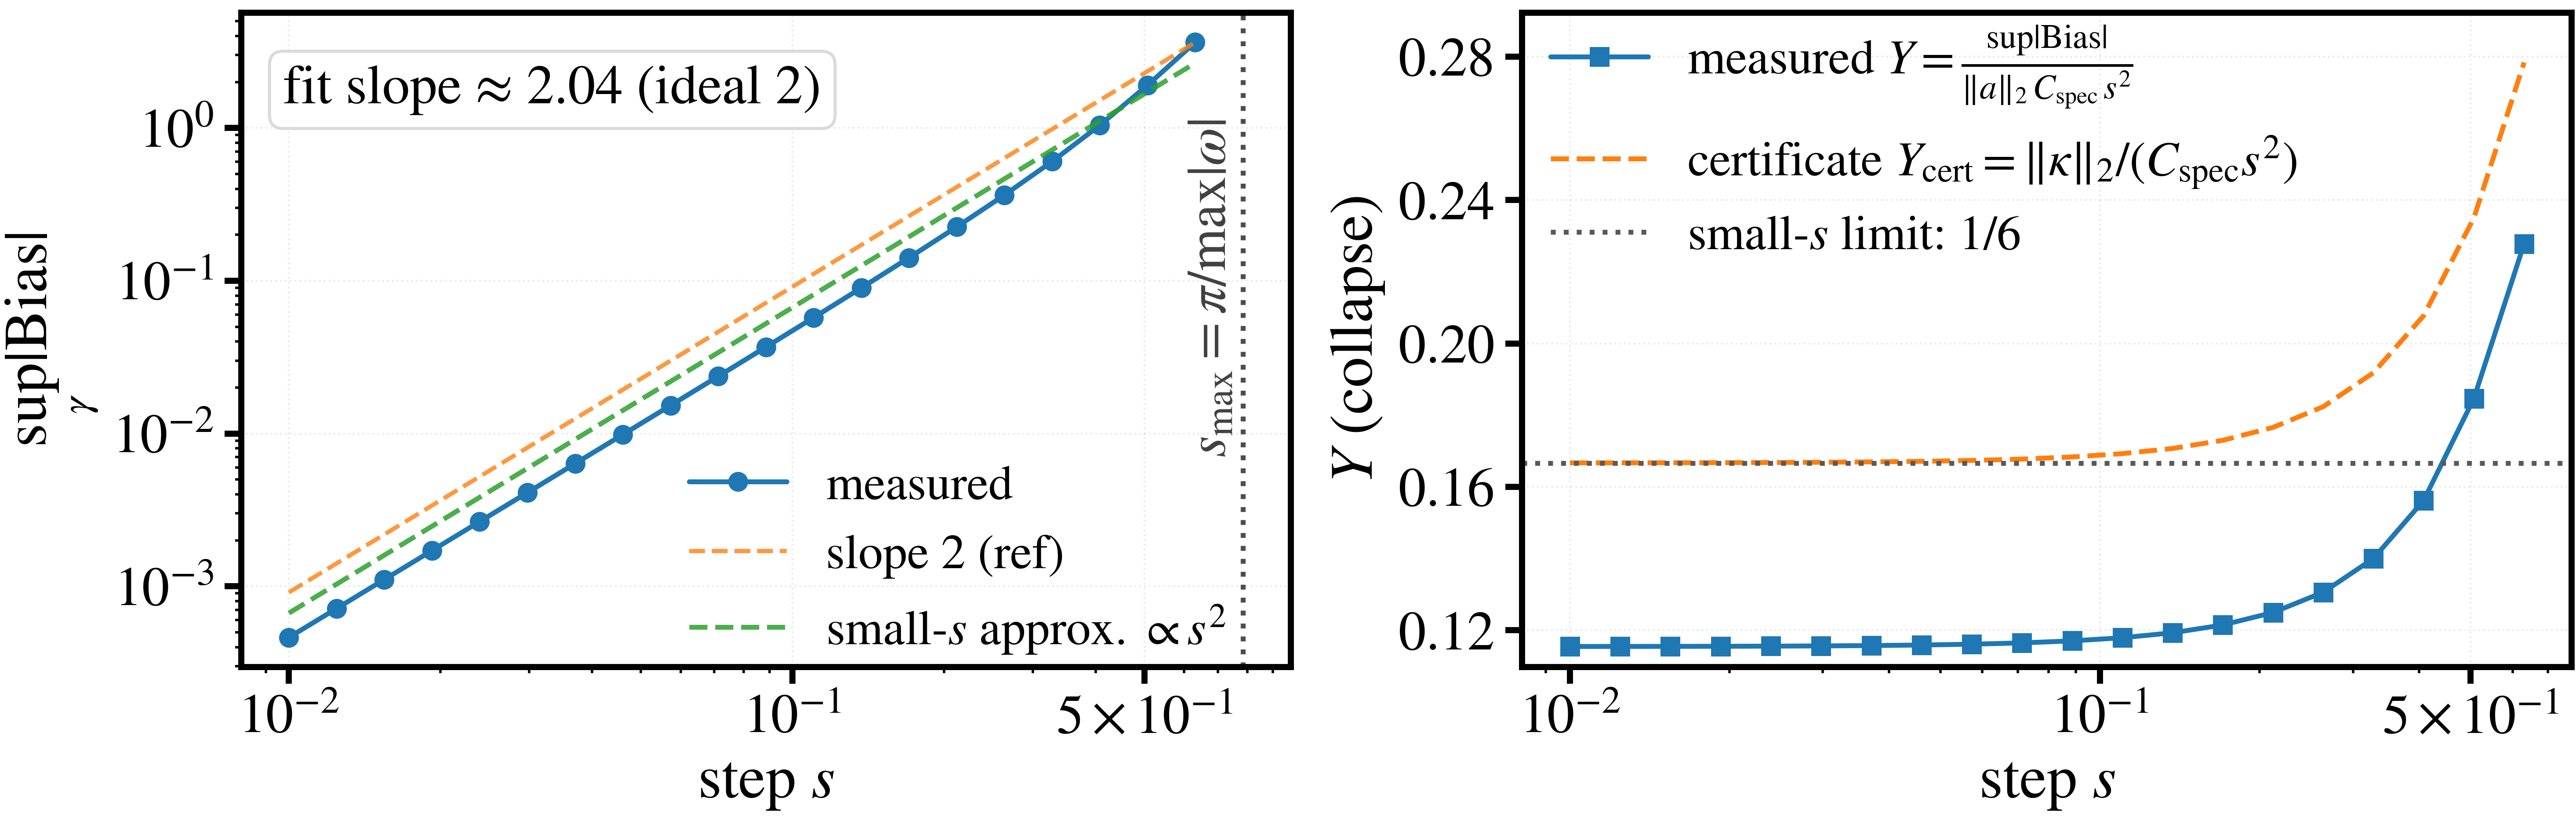

[Saved] figs_core\fig4_bias_vs_s.pdf  figs_core\fig4_bias_vs_s.png


In [11]:
# =============================
# I) Fig.4 — 偏置 vs 步长（左：log–log；右：归一化坍缩，小数刻度）
# =============================
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator, FuncFormatter, NullLocator

# 小工具：log-x 仅保留 10^-2、10^-1、5×10^-1 三个主刻度（按升序）
def _set_three_log_xticks(ax, s_grid):
    xticks = [t for t in (1e-2, 1e-1, 5e-1) if s_grid.min() <= t <= s_grid.max()]
    ax.set_xticks(xticks)
    lab = {1e-2: r"$10^{-2}$", 1e-1: r"$10^{-1}$", 5e-1: r"$5\times10^{-1}$"}
    ax.set_xticklabels([lab[t] for t in xticks])

# 视觉参数
FNT_LABEL = 18; FNT_TICK = 18; FNT_LEG = 16; FNT_BADGE = 18
LW_MAIN   = 1.6; LW_AUX   = 1.6; MS_SCAT   = 5.5

# 统一 s_grid
s_grid = np.logspace(-2.0, -0.2, 20)

# 实测 sup|Bias|
supvals = []
for s in s_grid:
    a_opt = opt_alpha_fixed_s(omega, s)
    supvals.append(sup_bias_numeric(omega, a, a_opt, s))
supvals = np.array(supvals)

# 频谱矩
A2 = float(np.sum(omega**2))
A4 = float(np.sum(omega**4))
A6 = float(np.sum(omega**6))
C_spec = math.sqrt(max(A6 - (A4**2)/A2, 1e-16))
a_norm2 = float(np.linalg.norm(a))

# 归一化
Y_norm = supvals / (a_norm2 * C_spec * (s_grid**2))

# 安全步长
wmax = float(np.max(np.abs(omega[np.abs(omega) > 0])))
s_safe = (np.pi / wmax) if wmax > 0 else np.inf

# 证书坍缩
Y_cert = []
for s in s_grid:
    a_opt = opt_alpha_fixed_s(omega, s)
    kappa = kappa_vec(omega, a_opt, s)
    Y_cert.append(np.linalg.norm(kappa) / (C_spec * (s**2)))
Y_cert = np.array(Y_cert)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4))

# ================= 左：原始 sup|Bias|—s（log–log） =================
ax = axes[0]
ax.loglog(s_grid, supvals, marker="o", lw=LW_MAIN, ms=MS_SCAT, label="measured")

mid = middle_slice_idx(len(s_grid), frac=0.6)
m, b = np.polyfit(np.log(s_grid[mid]), np.log(supvals[mid]), 1)
add_powerlaw_ref(ax, s_grid, supvals, slope=2, label="slope 2 (ref)")

approx = (a_norm2 * C_spec * (s_grid**2)) / 6.0
ax.loglog(s_grid, approx, "--", lw=LW_AUX, alpha=0.85, label=r"small-$s$ approx. $\propto s^2$")

if np.isfinite(s_safe):
    ax.axvline(s_safe, ls=":", lw=LW_AUX, color="0.3")
    ax.text(s_safe-0.02, ax.get_ylim()[1]*0.20, r"$s_{\max}=\pi/\max|\omega|$", rotation=90,
            ha="right", va="top", fontsize=FNT_TICK, color="0.25")

ax.fill_between(s_grid[mid], supvals[mid]*0.95, supvals[mid]*1.05, alpha=0.12, lw=0.0)

ax.set_xlabel(r"step $s$", fontsize=FNT_LABEL)
ax.set_ylabel(r"$\sup_\gamma|\mathrm{Bias}|$", fontsize=FNT_LABEL)
ax.tick_params(axis="both", labelsize=FNT_TICK, width=1.2, length=3.8, direction="out")

tbox = slope_box(ax, rf"fit slope ≈ {m:.2f} (ideal 2)", loc="tl", fontsize=FNT_BADGE)
tbox.set_position((0.04, 0.92))
ax.legend(
    frameon=False,
    fontsize=FNT_LEG,
    loc="lower right",
    bbox_to_anchor=(0.98, -0.05)
)

# ================= 右：归一化坍缩（x 对数，y 线性 → 小数刻度） =================
ax = axes[1]
ax.semilogx(s_grid, Y_norm, 's-', lw=LW_MAIN, ms=MS_SCAT,
            label=rf"measured $Y=\frac{{\sup|\mathrm{{Bias}}|}}{{\|a\|_2\,C_{{\rm spec}}\,s^2}}$")
ax.semilogx(s_grid, Y_cert, '--', lw=LW_AUX, label=r"certificate $Y_{\rm cert}=\|\kappa\|_2/(C_{\rm spec}s^2)$")
ax.axhline(1.0/6.0, ls=":", lw=LW_AUX, color="0.35", label=r"small-$s$ limit: $1/6$")

ax.set_xlabel(r"step $s$", fontsize=FNT_LABEL)
ax.set_ylabel(r"$Y$ (collapse)", fontsize=FNT_LABEL)
ax.tick_params(axis="both", labelsize=FNT_TICK, width=1.2, length=3.8, direction="out")

# y 轴小数格式（不使用科学计数法），并疏化刻度
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.2f}"))
ymin = min(Y_norm.min(), 1/6) * 0.95
ymax = max(Y_norm.max(), Y_cert.max(), 1/6) * 1.05
ax.set_ylim(ymin, ymax)
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both', min_n_ticks=3))
ax.yaxis.set_minor_locator(NullLocator())

# 单位徽标（可调）
ubox = unit_badge(ax, q=int(q_guess) if q_guess else None, loc="br", fontsize=FNT_BADGE)
# if ubox: ubox.set_position((0.50, 0.08))

ax.legend(
    frameon=False,
    fontsize=FNT_LEG,
    loc="upper right",
    bbox_to_anchor=(0.78, 1.05)
)

# ================= 仅保留 10^-2、10^-1、5×10^-1 三个主刻度 =================
for ax in axes:
    _set_three_log_xticks(ax, s_grid)

# ================= 轴线与刻度样式（保持你原来的加粗设置） =================
XY_AXIS_LW = 2     # x/y 轴线粗细
TICK_W     = 2.0   # 刻度线粗细
TICK_LEN   = 5.5   # 刻度线长度
LABEL_SIZE = 20    # 轴名称字号

for ax in axes:
    # 1) 仅加粗 bottom/left 两条轴线
    ax.spines['bottom'].set_linewidth(XY_AXIS_LW)
    ax.spines['left'].set_linewidth(XY_AXIS_LW)

    # 2) 仅加粗 bottom/left 对应的刻度（不影响 top/right）
    ax.tick_params(axis='x', width=TICK_W, length=TICK_LEN,
                   bottom=True, top=False, direction='out')
    ax.tick_params(axis='y', width=TICK_W, length=TICK_LEN,
                   left=True, right=False, direction='out')

    # 3) 放大轴名称字号
    ax.xaxis.label.set_size(LABEL_SIZE)
    ax.yaxis.label.set_size(LABEL_SIZE)

# 保持四周脊线可见与宽度
for ax in fig.axes:
    for side in ('top','right','bottom','left'):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(2)

fig.tight_layout()
savefig(fig, "fig4_bias_vs_s", show=True, width=980)


In [16]:
# %%
# ================= Fig.5（中心差分版 s*(M)；A: MSE vs M, B: s*(M) vs M；合并左右子图） =================
import numpy as np
import matplotlib.pyplot as plt
import gc
import pennylane as qml
from matplotlib.ticker import FuncFormatter, MaxNLocator, LinearLocator

# ---- 若未定义 ||C||_inf 的保守上界 Lambda，这里兜底一下（与前文一致） ----
if "Lambda" not in globals():
    Lambda = float(sum(abs(w) for *_, w in edges_w))

# ---- 中心差分版本的 s*(M)：只用 A6（真实用法） ----
def s_star_cd(M: int, Lambda: float, a: np.ndarray, omega: np.ndarray) -> float:
    A6 = float(np.sum(omega**6))
    denom = (np.linalg.norm(a)**2) * A6
    if denom <= 0:
        denom = abs(denom) + 1e-12
    return ((9.0 * (Lambda**2)) / (M * denom)) ** (1.0/6.0)

# ---- 构造 H_cost & 单一设备/QNode（shots=None；调用时传 shots=...） ----
coeffs, ops = [], []
for (i, j, w) in edges_w:
    coeffs.append(w)
    ops.append(qml.PauliZ(i) @ qml.PauliZ(j))
H_cost = qml.Hamiltonian(coeffs, ops)

_dev7 = qml.device("default.qubit", wires=n, shots=None)

@qml.qnode(_dev7)
def _circuit7(gamma_var):
    # |+>^n
    for w in range(n):
        qml.Hadamard(wires=w)
    for k in range(1, p+1):
        gk = gamma_var if k == ell else gammas_fixed[k-1]
        for (i, j, w) in edges_w:
            qml.IsingZZ(2.0 * gk * w, wires=[i, j])
        for q in range(n):
            qml.RX(2.0 * betas_fixed[k-1], wires=q)
    return qml.expval(H_cost)

def f_meas_cached(gamma: float, shots: int) -> float:
    return float(_circuit7(gamma, shots=int(shots)))

# ---- 参数（FAST=True 用于快速预览） ----
FAST = True
M_list = [100, 300, 1000, 3000, 6000, 12000]
REPS_MAIN = 20 if not FAST else 5
N_GAMMAS_MAIN = 64 if not FAST else 16

R_BOOTDATA = 50 if not FAST else 20        # 生成“重复数据集”的个数
REPS_BOOT_EACH = 5 if not FAST else 2      # 每个数据集内部重复估计次数
N_GAMMAS_BOOT_EACH = 32 if not FAST else 8 # 每个数据集里的 γ 点数
B_BOOT = 1000 if not FAST else 300         # bootstrap 次数

rng_shared = np.random.default_rng(20250101)
GAMMAS_MAIN = rng_shared.random(N_GAMMAS_MAIN) * 2*np.pi
GAMMAS_BOOT  = rng_shared.random(N_GAMMAS_BOOT_EACH) * 2*np.pi

def mse_at_M_cached(M: int, gammas: np.ndarray, reps=20, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    sstar = s_star_cd(M, Lambda, a, omega)
    alpha = 1.0 / (2.0 * sstar)
    gtrue = fprime_from_spectrum(omega, a, gammas)

    errs = []
    for _ in range(reps):
        f_plus  = np.array([f_meas_cached(g + sstar, shots=M) for g in gammas], dtype=float)
        f_minus = np.array([f_meas_cached(g - sstar, shots=M) for g in gammas], dtype=float)
        ghat = alpha * (f_plus - f_minus)
        errs.append(np.mean((ghat - gtrue)**2))
    return float(np.mean(errs)), float(sstar)

# ---- Fig.7A/7B 主曲线（均值） ----
rng_main = np.random.default_rng(12345)
mses_mean, sstars = [], []
for M in M_list:
    msev, ssv = mse_at_M_cached(M, GAMMAS_MAIN, reps=REPS_MAIN, rng=rng_main)
    mses_mean.append(msev); sstars.append(ssv)
mses_mean = np.array(mses_mean); sstars = np.array(sstars)

# ---- 为 Fig.7A 估计对数域 95% CI（log 正态近似） ----
mses_rep = np.zeros((R_BOOTDATA, len(M_list)), dtype=float)
rng_rep = np.random.default_rng(24680)
for r in range(R_BOOTDATA):
    for i, M in enumerate(M_list):
        msev, _ = mse_at_M_cached(M, GAMMAS_BOOT, reps=REPS_BOOT_EACH, rng=rng_rep)
        mses_rep[r, i] = msev

def log_CI_to_linear_errors(samples):
    ylog = np.log(samples)
    ybar = ylog.mean()
    se = ylog.std(ddof=1) / np.sqrt(len(ylog))
    ci = 1.96 * se
    mean_lin = np.exp(ybar)
    lo = np.exp(ybar - ci); hi = np.exp(ybar + ci)
    return mean_lin, (mean_lin - lo, hi - mean_lin)

y_mean, y_err = [], []
for i in range(len(M_list)):
    mlin, (elo, ehi) = log_CI_to_linear_errors(mses_rep[:, i])
    y_mean.append(mlin); y_err.append([elo, ehi])
y_mean = np.array(y_mean); y_err = np.array(y_err).T

mid = middle_slice_idx(len(M_list), frac=0.6)


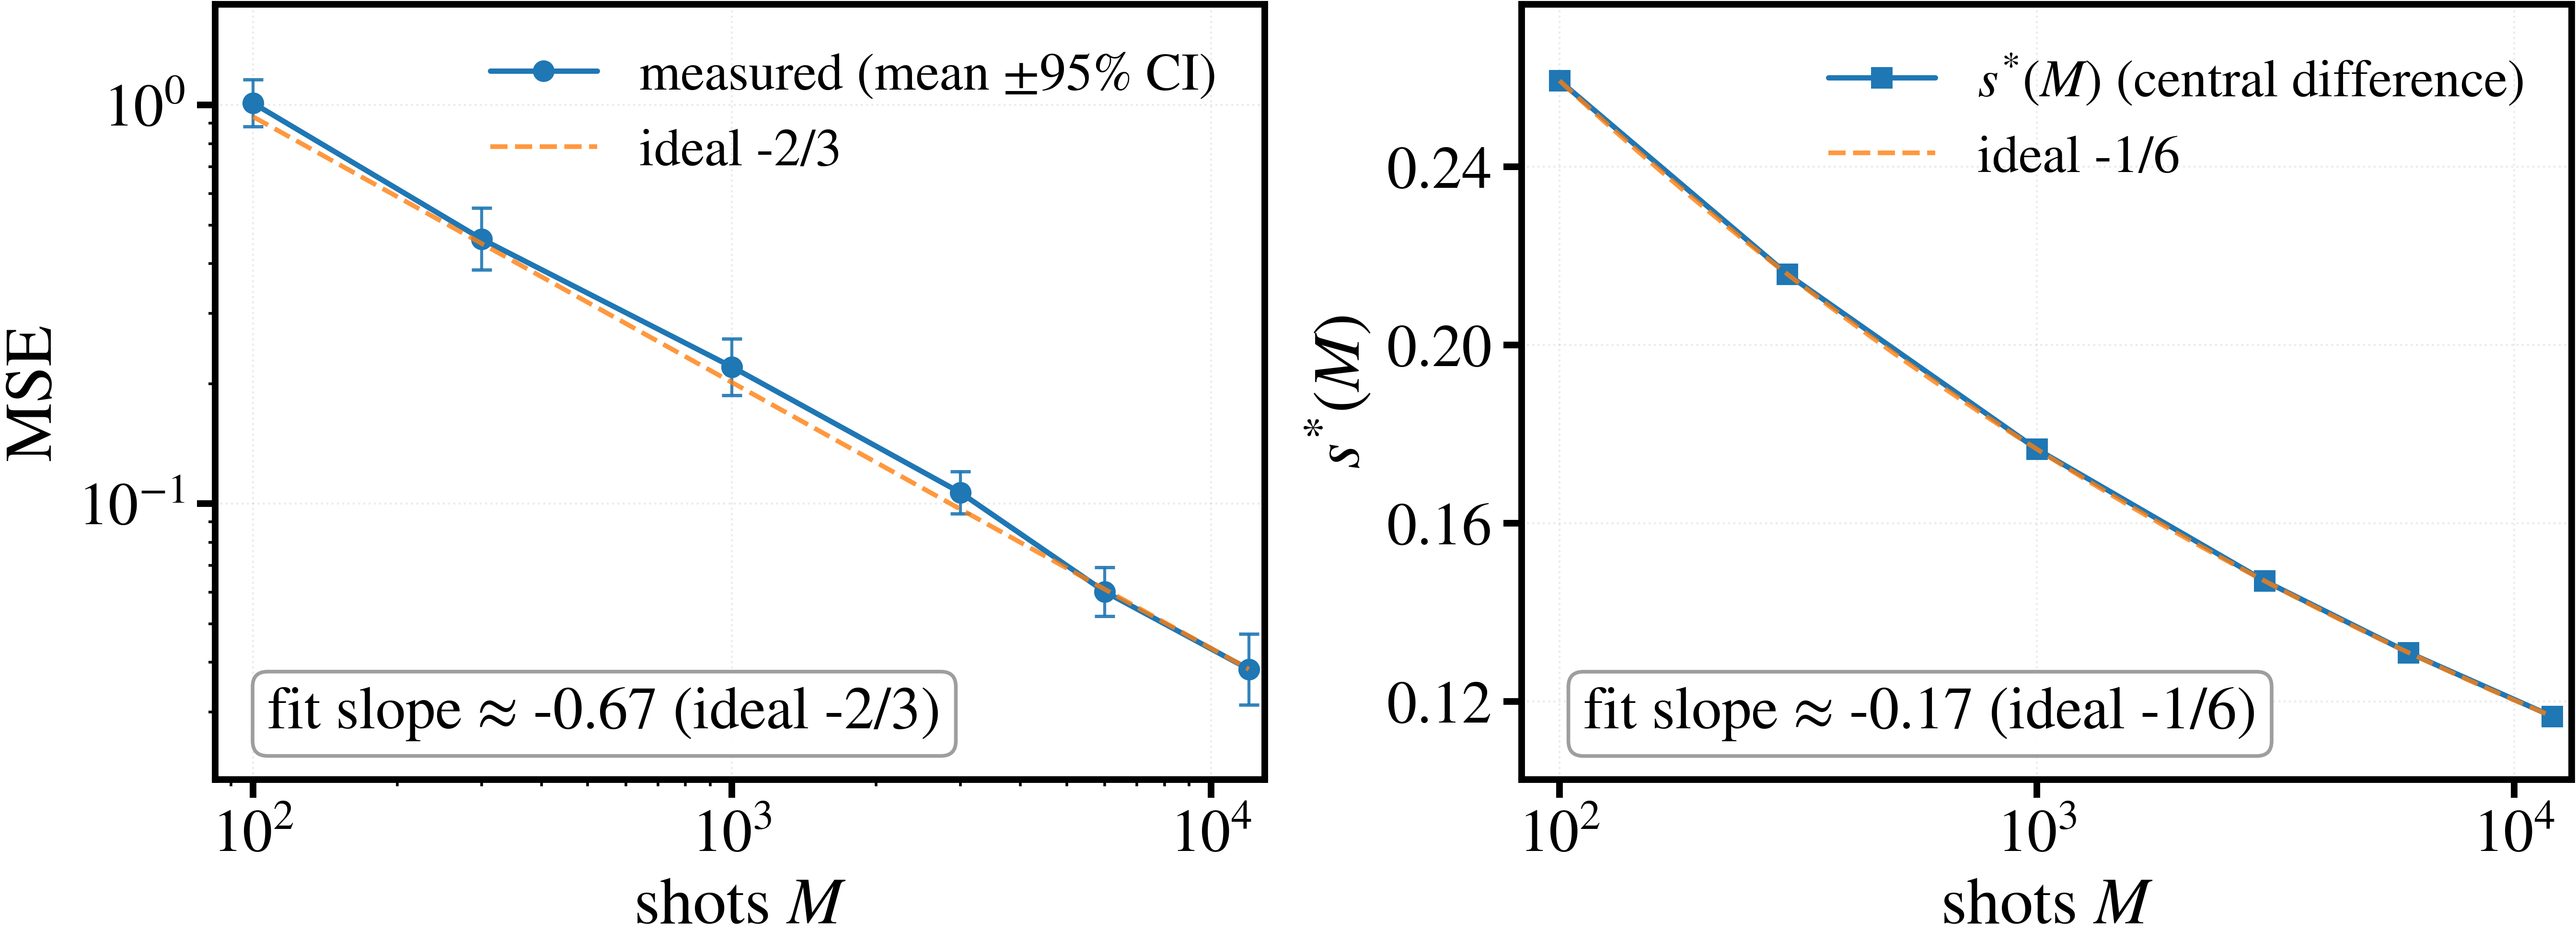

[Saved] figs_core\fig5a_mse_vs_M.pdf  figs_core\fig5a_mse_vs_M.png


5634

In [17]:
# %% ================= Fig.5（中心差分版 s*(M)；A: MSE vs M, B: s*(M) vs M） =================
import numpy as np
import matplotlib.pyplot as plt
import gc
from matplotlib.ticker import FuncFormatter, MaxNLocator

# ---------- 假设 M_list, y_mean, y_err, sstars, mid 已定义 ----------
# （在前面运行主计算代码即可）

# ---------- 全局视觉参数 ----------
FNT_LABEL = 18
FNT_TICK = 18
FNT_LEG = 16
FNT_BADGE = 18
LW_MAIN = 1.6
LW_AUX = 1.6
MS_SCAT = 5.5

# ---------- 创建画布 ----------
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
axA, axB = axes

# ==============================
# A 图 (MSE vs M) —— log-log
# ==============================
(lnA,) = axA.loglog(M_list, y_mean, marker="o", lw=LW_MAIN, ms=MS_SCAT,
                    label="measured (mean ±95% CI)")
axA.errorbar(M_list, y_mean, yerr=y_err, fmt="none", lw=0.9, capsize=3,
             color=lnA.get_color(), alpha=0.9)
add_powerlaw_ref(axA, M_list, y_mean, slope=-2/3, label="ideal -2/3")

# 拟合斜率徽章
X = np.log(np.array(M_list)[mid])
Y = np.log(y_mean[mid])
mA, _ = np.polyfit(X, Y, 1)
axA.text(0.05, 0.05, rf"fit slope ≈ {mA:.2f} (ideal -2/3)",
         transform=axA.transAxes, ha="left", va="bottom",
         fontsize=FNT_BADGE,
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.6", lw=1.1, alpha=0.95))

axA.set_xlabel(r"shots $M$", fontsize=FNT_LABEL)
axA.set_ylabel("MSE", fontsize=FNT_LABEL)
axA.tick_params(axis="both", labelsize=FNT_TICK, width=2.0, length=5.5, direction="out")
axA.legend(frameon=False, loc="upper right", fontsize=FNT_LEG)
axA.margins(x=0.05, y=0.12)

# ✅ 让左图右边也稍微宽一点
X_MARGIN_FACTOR = 1.08
axA.set_xlim(M_list[0]/1.2, M_list[-1]*X_MARGIN_FACTOR)

# ==============================
# B 图 (s*(M) vs M) —— semilogx（x 对数、y 线性）
# ==============================
axB.semilogx(M_list, sstars, marker="s", lw=LW_MAIN, ms=MS_SCAT,
             label=r"$s^{*}(M)$ (central difference)")
add_powerlaw_ref(axB, M_list, sstars, slope=-1/6, label="ideal -1/6")

# ✅ y 轴：小数 + 等间距 + 上下留白
axB.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.2f}"))
ymin_d, ymax_d = float(np.min(sstars)), float(np.max(sstars))
yspan = max(ymax_d - ymin_d, 1e-9)
UP_PAD, DOWN_PAD = 0.12, 0.10
ylim_low = ymin_d - DOWN_PAD * yspan
ylim_high = ymax_d + UP_PAD * yspan
axB.set_ylim(ylim_low, ylim_high)
axB.yaxis.set_major_locator(MaxNLocator(nbins=5, prune=None))
axB.minorticks_off()

# 拟合斜率徽章
XB = np.log(np.array(M_list)[mid])
YB = np.log(sstars[mid])
mB, _ = np.polyfit(XB, YB, 1)
axB.text(0.70, 0.12, rf"fit slope ≈ {mB:.2f} (ideal -1/6)",
         transform=axB.transAxes, ha="right", va="top",
         fontsize=FNT_BADGE,
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.6", lw=1.1, alpha=0.95))

axB.set_xlabel(r"shots $M$", fontsize=FNT_LABEL)
axB.set_ylabel(r"$s^{*}(M)$", fontsize=FNT_LABEL)
axB.tick_params(axis="both", labelsize=FNT_TICK, width=2.0, length=5.5, direction="out")
axB.legend(frameon=False, loc="upper right", fontsize=FNT_LEG)
axB.margins(x=0.05, y=0.12)

# ✅ 右图 x 轴右边再扩一点点
X_MARGIN_FACTOR = 1.10   # 可改成 1.12 或 1.15 看效果
axB.set_xlim(M_list[0]/1.2, M_list[-1]*X_MARGIN_FACTOR)

# ==============================
# 统一四边框线宽 & 标签字号
# ==============================
XY_AXIS_LW = 2.0
for ax in axes:
    for side in ('top','right','bottom','left'):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(XY_AXIS_LW)
    ax.xaxis.label.set_size(20)
    ax.yaxis.label.set_size(20)

fig.tight_layout()
savefig(fig, "fig5a_mse_vs_M", show=True, width=980)
plt.close(fig)
gc.collect()
